## 2.5.自动微分
深度学习框架通过自动计算导数，即自动微分（automatic differentiation）来加快求导。 实际中，根据设计好的模型，系统会构建一个计算图（computational graph）， 来跟踪计算是哪些数据通过哪些操作组合起来产生输出。 自动微分使系统能够随后反向传播梯度。 这里，反向传播（backpropagate）意味着跟踪整个计算图，填充关于每个参数的偏导数。

### 2.5.1.简单例子
假想对函数$y=2\mathbf{x}^{\top}\mathbf{x}$关于列向量$x$求导

In [2]:
import torch
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

在我们计算y关于x的梯度之前，需要一个地方来存储梯度。 重要的是，我们不会在每次对一个参数求导时都分配新的内存。 因为我们经常会成千上万次地更新相同的参数，每次都分配新的内存可能很快就会将内存耗尽。 注意，一个标量函数关于向量x的梯度是向量，并且与
具有相同的形状。

In [3]:
x.requires_grad_(True)
x.grad # 默认值是None

In [4]:
y = 2 * torch.dot(x,x)
y

tensor(28., grad_fn=<MulBackward0>)

x是一个长度为4的向量，计算x和x的点积，得到了我们赋值给y的标量输出。 接下来，通过调用反向传播函数来自动计算y关于x每个分量的梯度，并打印这些梯度。

In [5]:
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

In [6]:
# 验证
x.grad == 4 * x

tensor([True, True, True, True])

In [8]:
# 默认情况下，pytorch会累积梯度，需要清除之前的值
x.grad.zero_()
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

### 2.5.2.非标量变量的反向传播
当y不是标量时，向量y关于向量x的导数的最自然解释是一个矩阵。 对于高阶和高维的y和x，求导的结果可以是一个高阶张量。

然而，虽然这些更奇特的对象确实出现在高级机器学习中（包括深度学习中）， 但当调用向量的反向计算时，我们通常会试图计算一批训练样本中每个组成部分的损失函数的导数。 这里，我们的目的不是计算微分矩阵，而是单独计算批量中每个样本的偏导数之和。

In [10]:
# 对非标量调用backward需要传入一个gradient参数，该参数指定微分函数关于self的梯度
# 本例只想求偏导数的和，所以传递一个1的梯度是合适的
x.grad.zero_()
y = x * x
y.sum().backward()
x.grad


tensor([0., 2., 4., 6.])

### 2.5.3.分离计算
有时，我们希望将某些计算移动到记录的计算图之外。 例如，假设y是作为x的函数计算的，而z则是作为y和x的函数计算的。 想象一下，我们想计算z关于x的梯度，但由于某种原因，希望将y视为一个常数， 并且只考虑到x在y被计算后发挥的作用。

这里可以分离y来返回一个新变量u，该变量与y具有相同的值， 但丢弃计算图中如何计算y的任何信息。 换句话说，梯度不会向后流经u到x。 因此，下面的反向传播函数计算z=u * x关于x的偏导数，同时将u作为常数处理， 而不是z=x * x * x关于x的偏导数。

In [12]:
x.grad.zero_()
y = x * x
u = y.detach()
z = u * x

z.sum().backward()
x.grad==u

tensor([True, True, True, True])

### 2.5.4.Python控制流的梯度计算
使用自动微分的一个好处是： 即使构建函数的计算图需要通过Python控制流（例如，条件、循环或任意函数调用），我们仍然可以计算得到的变量的梯度。 在下面的代码中，while循环的迭代次数和if语句的结果都取决于输入a的值。

In [13]:
def f(a):
    b = a *2
    # 当b的范数(b的所有元素的皮肤和的平方根)大于或等于1000为止
    while b.norm() < 1000: 
        b = b *2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

In [17]:
a = torch.randn(size=(),requires_grad=True)
d = f(a)
d.backward()

tensor(1563.5010, grad_fn=<MulBackward0>)

In [18]:
a.grad == d/a

tensor(True)

使$ f(x) = sin(x) $,绘制$ f(x) $ 和$ df(x)/dx $ 的图像，其中后者不使用$ f'(x) = cos(x)$


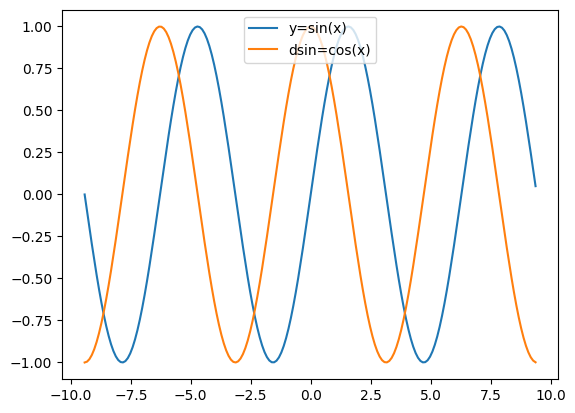

In [21]:
import torch
import matplotlib.pyplot as plt
import numpy as np
x = torch.arange(-3*np.pi,3*np.pi,0.1,requires_grad=True)
y = torch.sin(x)

y.sum().backward()

plt.plot(x.detach(),y.detach(),label='y=sin(x)')
plt.plot(x.detach(),x.grad,label='dsin=cos(x)')
plt.legend(loc='upper center')
plt.show()